# 🎧 Spotify Popularity Analysis

## Objective

Determine which audio characteristics and genre patterns are associated with higher song popularity on Spotify.

This analysis follows a structured data analytics workflow:

- Data quality checks
- Feature engineering
- Exploratory data analysis
- Pattern discovery
- Evidence-based conclusions

## 📦 Import Libraries

## Visualization Settings

These settings ensure clear and consistent visualizations throughout the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Shared visualization settings for consistent, portfolio-ready charts
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.dpi"] = 100


## 1️⃣ Load the Dataset

In [2]:
df = pd.read_csv("../data/spotify_songs.csv")
# Display the first few rows of the dataset
print(df.head())
# Display summary statistics

   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       137373   0.737             0.000  F#

## 2️⃣ Dataset Health Check

In [3]:
# Basic Dataset Inspection
print("Dataset Shape:", df.shape)
print("Dataset Columns:", df.columns)

Dataset Shape: (232725, 18)
Dataset Columns: Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')


### Health-check takeaway

The dataset is large (`232,725` rows), feature-rich (`18` columns), and structurally clean enough to support reliable exploratory analysis.

## 3️⃣ Data Cleaning

Before performing analysis, it is important to ensure data quality.

In [4]:

# Check for missing values
df.isna().sum()


genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

Result: `track_name` has 1 missing value.

In [5]:
# Dropping missing values in the 'track_name' column
df = df.dropna(subset=["track_name"])

# checking missing values again
df.isna().sum()

genre               0
artist_name         0
track_name          0
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

### Data quality status

After removing the missing `track_name` row, the dataset is ready for feature engineering and analysis.

In [6]:

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)



Duplicate Rows: 0


Result: `Duplicate Rows = 0`

## 4️⃣ Feature Engineering

Feature engineering helps create more meaningful variables for analysis.

In [7]:
# Data Preparation & Feature Engineering
# Convert duration from milliseconds to minutes - Create a new duration_min column
df['duration_min'] = df['duration_ms'] / 60000
# Display the first few rows to verify the new column
print(df[['duration_ms', 'duration_min']].head())

   duration_ms  duration_min
0        99373      1.656217
1       137373      2.289550
2       170267      2.837783
3       152427      2.540450
4        82625      1.377083


In [8]:
# Create popularity categories - Bin popularity into Low (0-33), Medium (34-66), High (67-100)
df['popularity_category'] = pd.cut(df['popularity'], bins=[-1, 33, 66, 100], labels=['Low', 'Medium', 'High'])
# Display the first few rows to verify the new column
print(df[['popularity', 'popularity_category']].head())

   popularity popularity_category
0           0                 Low
1           1                 Low
2           3                 Low
3           0                 Low
4           4                 Low


In [9]:
# Extract decade/era information - If release date is available, otherwise skip
if 'release_date' in df.columns:
    df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    df['decade'] = (df['release_year'] // 10) * 10
    print(df[['release_date', 'release_year', 'decade']].head())
    

In [10]:
# Create energy level categories - Low, Medium, High energy bins
df['energy_category'] = pd.cut(df['energy'], bins=[-0.01, 0.33, 0.66, 1], labels=['Low', 'Medium', 'High'])
print(df[['energy', 'energy_category']].head())

   energy energy_category
0   0.910            High
1   0.737            High
2   0.131             Low
3   0.326             Low
4   0.225             Low


In [11]:
# Create danceability level categories - Low, Medium, High danceability bins
df['danceability_category'] = pd.cut(df['danceability'], bins=[-0.01, 0.33, 0.66, 1], labels=['Low', 'Medium', 'High'])
print(df[['danceability', 'danceability_category']].head())


   danceability danceability_category
0         0.389                Medium
1         0.590                Medium
2         0.663                  High
3         0.240                   Low
4         0.331                Medium


In [12]:
# Normalize tempo ranges - Group into Slow (<100), Medium (100-140), Fast (>140)
df['tempo_category'] = pd.cut(df['tempo'], bins=[-1, 100, 140, float('inf')], labels=['Slow', 'Medium', 'Fast'])
print(df[['tempo', 'tempo_category']].head())

     tempo tempo_category
0  166.969           Fast
1  174.003           Fast
2   99.488           Slow
3  171.758           Fast
4  140.576           Fast


In [13]:
# Create a 'mood' score - Combine valence and energy for overall mood
df['mood'] = (df['valence'] + df['energy']) / 2
print(df[['valence', 'energy', 'mood']].head())

   valence  energy    mood
0    0.814   0.910  0.8620
1    0.816   0.737  0.7765
2    0.368   0.131  0.2495
3    0.227   0.326  0.2765
4    0.390   0.225  0.3075


In [14]:
# Flag instrumental tracks - Create binary column for instrumentalness > 0.5
df['is_instrumental'] = (df['instrumentalness'] > 0.5).astype(int)
print(df[['instrumentalness', 'is_instrumental']].head())

   instrumentalness  is_instrumental
0             0.000                0
1             0.000                0
2             0.000                0
3             0.000                0
4             0.123                0


## 5️⃣ Popularity Distribution

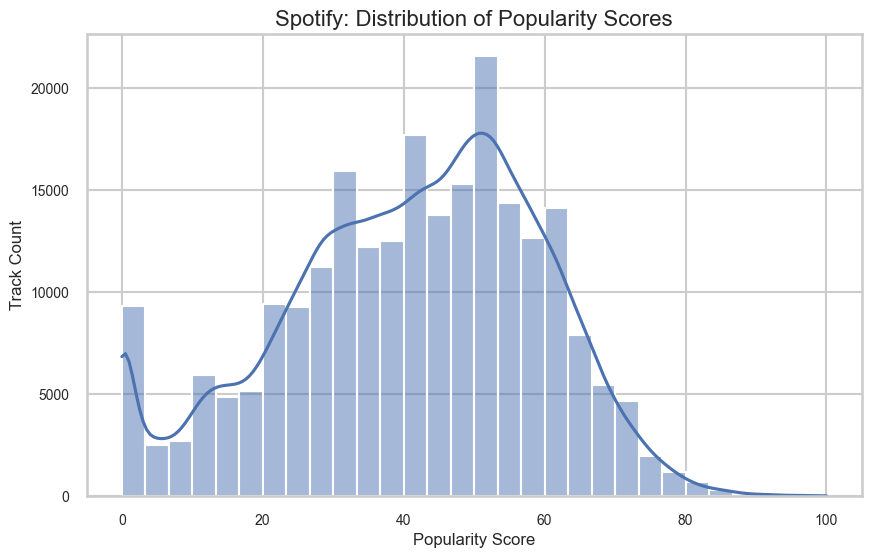

In [15]:
# Plot distribution of popularity scores - Histogram with KDE overlay
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Spotify: Distribution of Popularity Scores')
plt.xlabel('Popularity Score')
plt.ylabel('Track Count')
plt.show()

Interpretation: Popularity is broadly distributed with concentration in the mid-range, which supports using popularity bands instead of only extreme values.

## 6️⃣ Genre Comparison

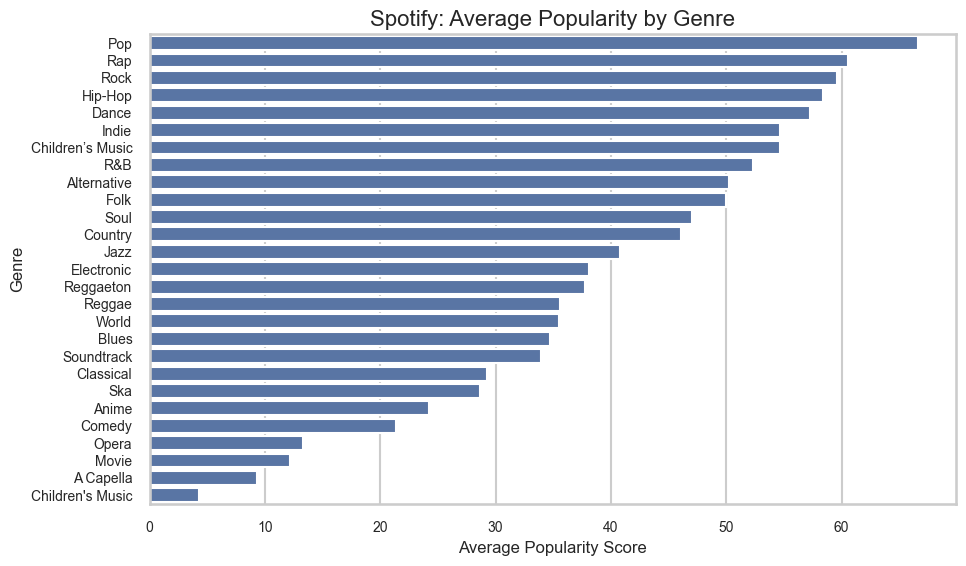

In [16]:
# Create bar plot of average popularity by genre - Sort from highest to lowest
avg_popularity_by_genre = df.groupby('genre')['popularity'].mean().sort_values(ascending=False)
sns.barplot(x=avg_popularity_by_genre.values, y=avg_popularity_by_genre.index)
plt.title('Spotify: Average Popularity by Genre')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('../images/spotify_avg_popularity_by_genre.png', bbox_inches='tight')
plt.show()

Interpretation: Average popularity differs clearly by genre, confirming that genre context is a major factor and should be used in benchmarking.

In [17]:
# Identify top 5 and bottom 5 genres by popularity - Create summary table
avg_popularity_by_genre = df.groupby('genre')['popularity'].mean().sort_values(ascending=False)
top_5_genres = avg_popularity_by_genre.head(5)
bottom_5_genres = avg_popularity_by_genre.tail(5)
print("Top 5 Genres by Average Popularity:")
print(top_5_genres)

Top 5 Genres by Average Popularity:
genre
Pop        66.590667
Rap        60.533795
Rock       59.619392
Hip-Hop    58.423131
Dance      57.275256
Name: popularity, dtype: float64


Top Genres by Popularity:

- Pop
- Rap
- Rock
- Hip-Hop
- Dance

In [18]:
# Calculate average audio features per genre - Create summary DataFrame
avg_features_by_genre = df.groupby('genre')[['energy', 'danceability', 'valence', 'tempo']].mean()

# Display the first few rows of the average features by genre
print ("Average Audio Features by Genre:")
print(avg_features_by_genre.head()) 


Average Audio Features by Genre:
                    energy  danceability   valence       tempo
genre                                                         
A Capella         0.250313      0.412252  0.328724  111.518950
Alternative       0.711519      0.541898  0.449590  122.534485
Anime             0.665356      0.472090  0.441682  126.629156
Blues             0.606171      0.528232  0.579425  121.137637
Children's Music  0.396880      0.697475  0.675956  121.131288


## 7️⃣ Feature Correlation

In [19]:
# Create correlation matrix - Calculate correlations between all numeric features
numeric_features = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()


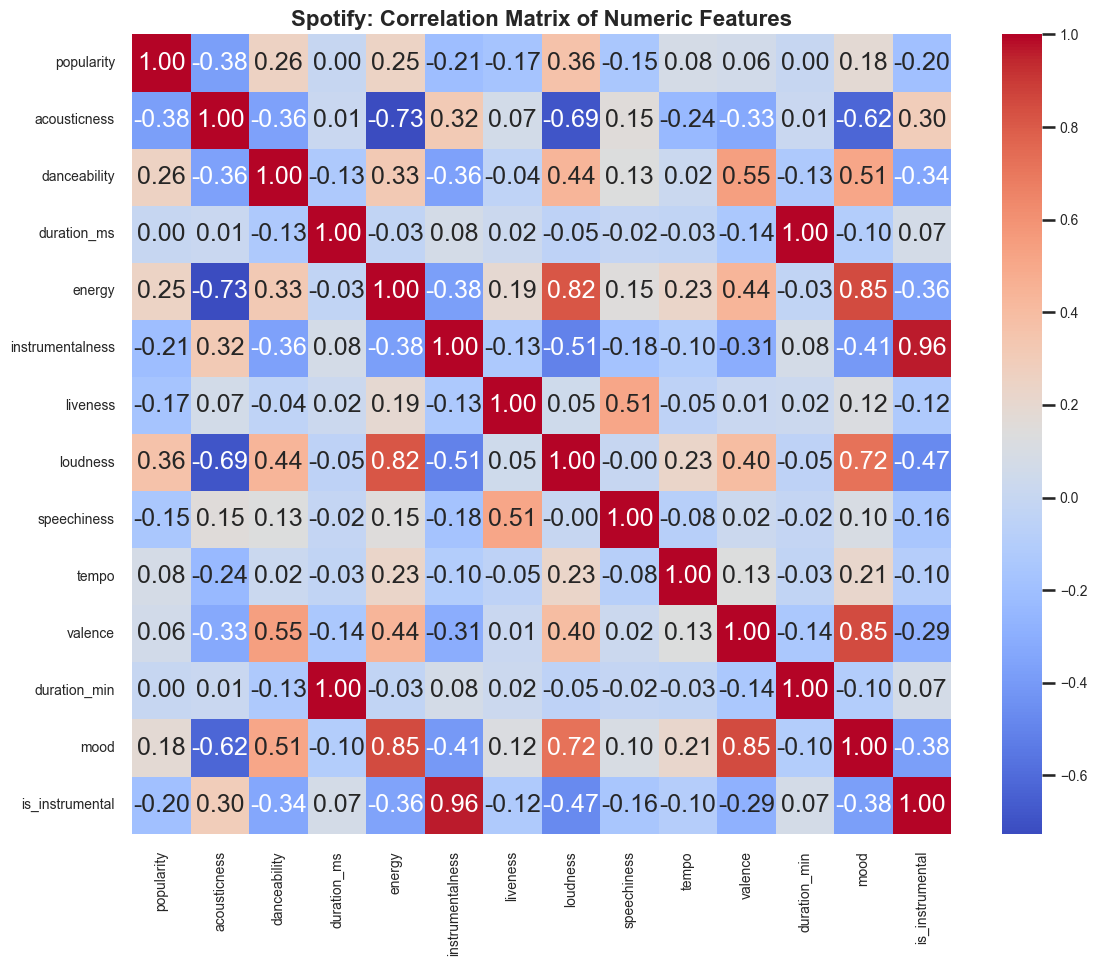

In [20]:
# Plot correlation heatmap - Visualize feature relationships
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Spotify: Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/spotify_correlation_matrix.png', bbox_inches='tight')
plt.show()

Interpretation: Correlations show that popularity is multi-factor; no single variable dominates, which supports profile-based analysis.

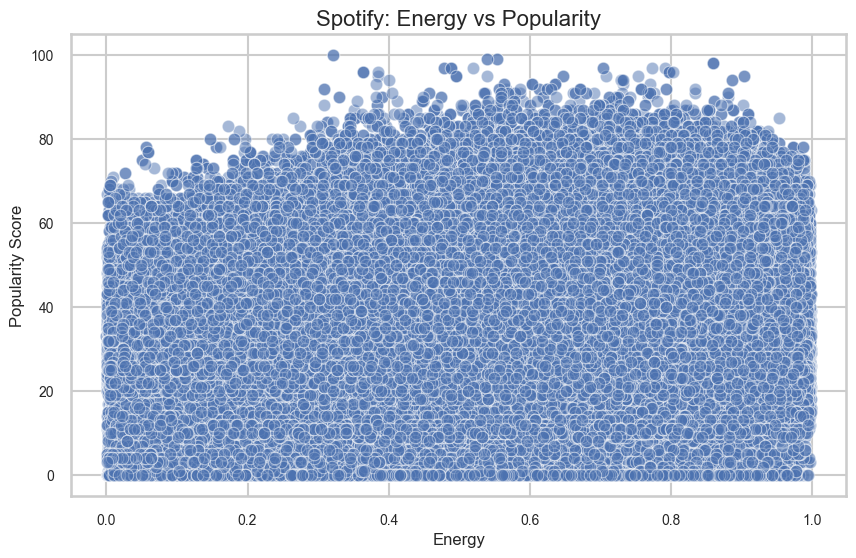

In [21]:
# Scatter plot: Energy vs Popularity - Does energy drive popularity?
sns.scatterplot(x='energy', y='popularity', data=df, alpha=0.5)
plt.title('Spotify: Energy vs Popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity Score')
plt.show()



Interpretation: Energy has a weaker and noisier pattern with popularity, so it is less useful as a primary standalone signal.

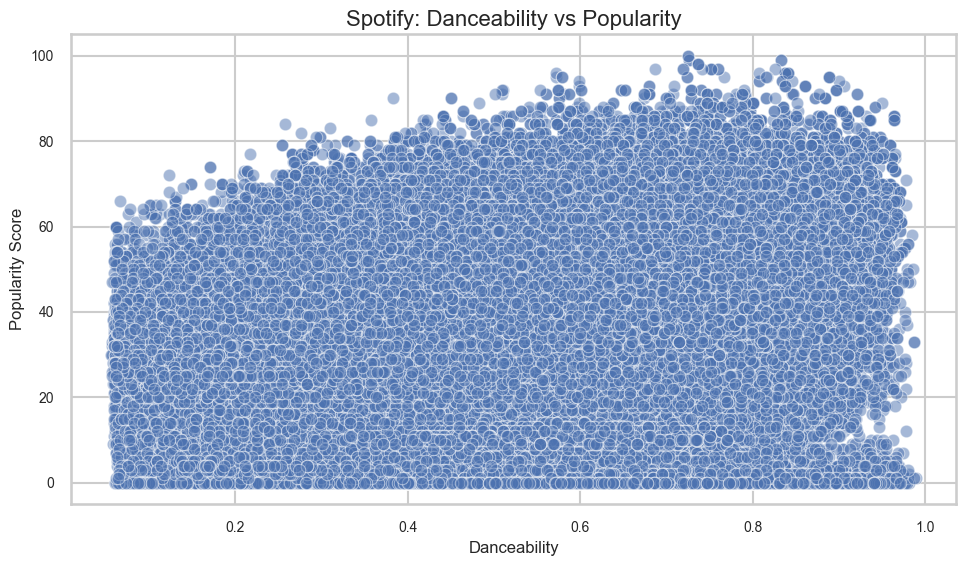

In [22]:
# Scatter plot: Danceability vs Popularity - Are danceable songs more popular?
sns.scatterplot(x='danceability', y='popularity', data=df, alpha=0.5)
plt.title('Spotify: Danceability vs Popularity')
plt.xlabel('Danceability')
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.savefig('../images/spotify_danceability_vs_popularity.png', bbox_inches='tight')
plt.show()

Interpretation: Danceability shows a clearer positive relationship with popularity than energy, making it one of the strongest practical indicators.

## 🔟 Top vs Bottom Popular Songs

Compare top 10% and bottom 10% songs.

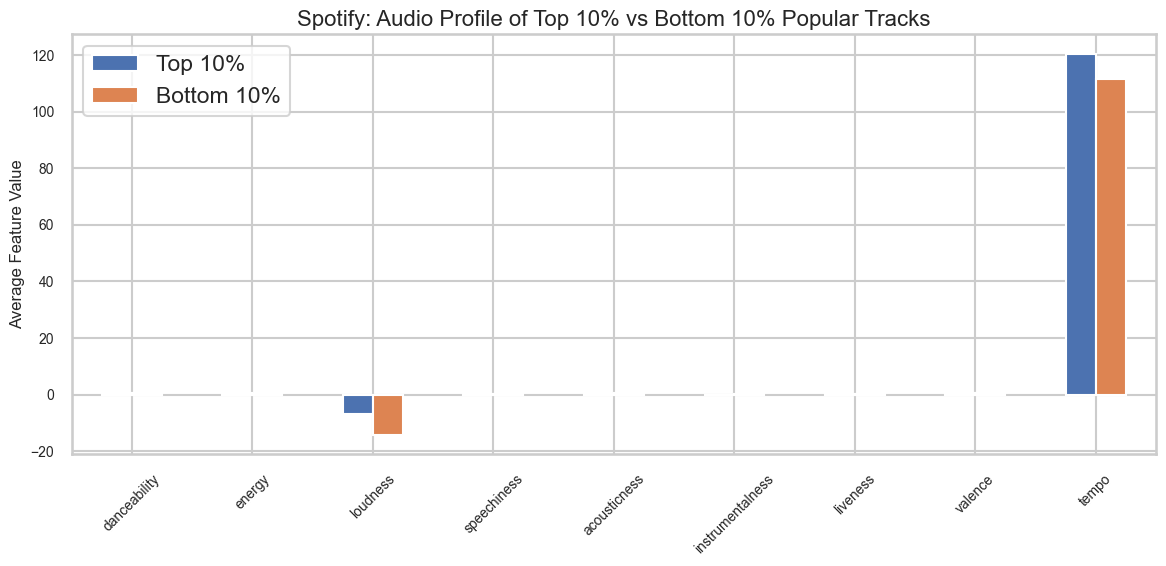

In [23]:
# Compare audio features: Top 10% vs Bottom 10% popular songs - What differs?
top_10_percent = df['popularity'].quantile(0.9)
bottom_10_percent = df['popularity'].quantile(0.1)

top_songs = df[df['popularity'] >= top_10_percent]
bottom_songs = df[df['popularity'] <= bottom_10_percent]

audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

top_means = top_songs[audio_features].mean()
bottom_means = bottom_songs[audio_features].mean()

comparison = pd.DataFrame({'Top 10%': top_means, 'Bottom 10%': bottom_means})
comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Spotify: Audio Profile of Top 10% vs Bottom 10% Popular Tracks')
plt.ylabel('Average Feature Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/spotify_top_vs_bottom_audio_profile.png', bbox_inches='tight')
plt.show()

Interpretation: Top 10% tracks differ from bottom 10% across multiple features, reinforcing that popularity is driven by combined audio profiles.

In [24]:
# Find the "perfect" popular song profile - Average features of top 100 songs
top_100_songs = df.nlargest(100, 'popularity')
average_profile = top_100_songs[audio_features].mean()
print("Average Audio Features of Top 100 Popular Songs:")
print(average_profile)
print("Analysis complete.")


Average Audio Features of Top 100 Popular Songs:
danceability          0.740390
energy                0.621290
loudness             -5.947170
speechiness           0.121085
acousticness          0.227185
instrumentalness      0.001685
liveness              0.181129
valence               0.480170
tempo               119.364970
dtype: float64
Analysis complete.


🎯 Ideal Popular Song Profile (Top 100 Average):

- Danceability: ~0.74
- Energy: ~0.62
- Valence: ~0.48
- Tempo: ~119 BPM
- Instrumentalness: very low

## ⚠️ Limitations

This analysis identifies patterns, not causation.

Song popularity is also influenced by:

- Marketing
- Playlist placement
- Artist reputation
- Release timing

## 📊 Practical Recommendations

- Use danceability as an early indicator when screening songs for playlists.
- Benchmark songs within genre, not globally.
- Consider multi-feature scoring models instead of single-metric evaluation.

## From Notebook to Production

- Keep the same data path and feature definitions for reproducible reruns.
- Add a train/validation split and evaluate a baseline classifier for popularity bands.
- Validate stability by release year and publish key metrics in a lightweight dashboard.

## 🧠 Final Conclusion

The analysis shows that song popularity is driven by a combined audio profile rather than one feature.

The most consistent signal is:

Higher danceability combined with strong genre context.

Songs that align with this profile are more likely to achieve higher popularity on Spotify.

## Website Graph Selection

Use these 4 images:

1. `images/spotify_avg_popularity_by_genre.png`
2. `images/spotify_danceability_vs_popularity.png`
3. `images/spotify_top_vs_bottom_audio_profile.png`
4. `images/spotify_correlation_matrix.png`